# AI impact on students: Predicting burnout risk

### Setup instructions:
1. Download the dataset from Kaggle: https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students
2. Make sure the dataset file is named "ai_student_impact_dataset (1).csv" and that it is in the same folder as this notebook!

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn
print("Environment setup complete. Libraries installed.")

Environment setup complete. Libraries installed.


## Importing libraries and loading data
First, we load necessary Python packages for data manipulation, visualization and machine learning. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10

data_path = 'ai_student_impact_dataset (1).csv'

try:
    df = pd.read_csv(data_path)
    print(f"Dataset loaded successfully. Shape: {df.shape[0]} rows across {df.shape[1]} columns.\n")
    print(df.head())
except FileNotFoundError:
    print("ERROR: Dataset not found!")
    print("Please ensure the dataset file 'ai_student_impact_dataset (1).csv' is in the same folder as this notebook!")

Dataset loaded successfully. Shape: 50000 rows across 16 columns.

   Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0      100001     Humanities        Senior             2.418   
1      100002        Medical        Junior             3.821   
2      100003       Business      Freshman             3.398   
3      100004       Business        Senior             3.789   
4      100005           STEM     Sophomore             3.635   

   Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0               23.31       Copywriting/Drafting                 Beginner   
1                1.12                   Ideation                 Advanced   
2               21.26        Summarizing_Reading                 Beginner   
3                1.82       Copywriting/Drafting             Intermediate   
4                9.29  Debugging/Troubleshooting                 Advanced   

   Tool_Diversity  Paid_Subscription  Traditional_Study_Hours  \
0               1   

## Preprocessing
Before building our model, we need to clean the data and prepare it for the algorithm. 
* drop identifiers like `Student_ID` which have no effect on our target variable.
* convert categorical text data into numerical format using One-Hot Encoding.

In [3]:
if 'Student_ID' in df.columns:
    df = df.drop(columns=['Student_ID'])

X = df.drop(columns=['Burnout_Risk_Level'])
y = df['Burnout_Risk_Level']

categorical_cols = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Data preprocessing complete. Features expanded to {X_encoded.shape[1]} columns due to encoding.")

Data preprocessing complete. Features expanded to 25 columns due to encoding.


C:\Users\Victu\AppData\Local\Temp\ipykernel_47340\1803314114.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


## Visualizing the distribution of our target variable (`Burnout_Risk`)


C:\Users\Victu\AppData\Local\Temp\ipykernel_47340\1004141279.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Burnout_Risk_Level', order=['Low', 'Medium', 'High'], palette='viridis')


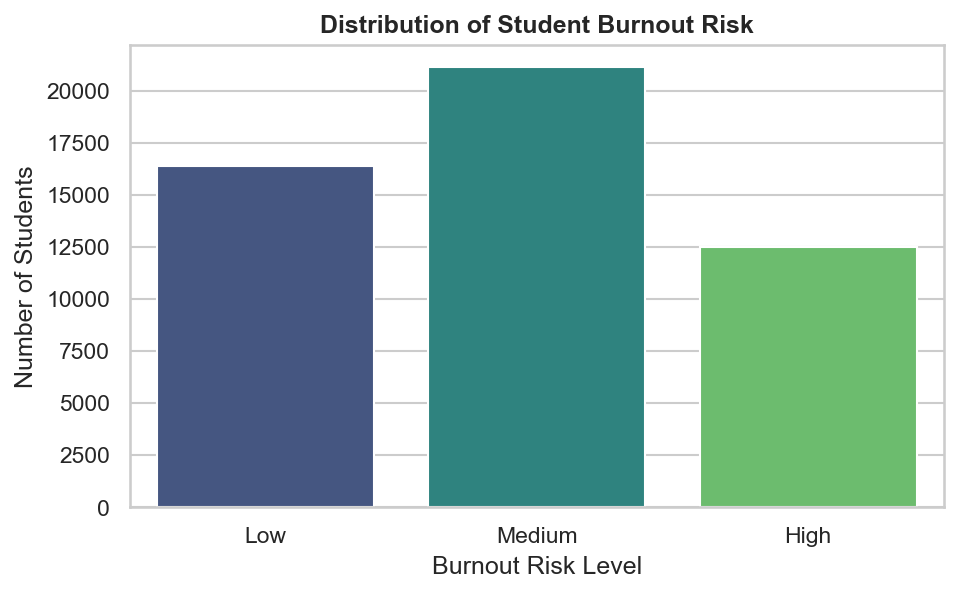

In [4]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Burnout_Risk_Level', order=['Low', 'Medium', 'High'], palette='viridis')
plt.title('Distribution of Student Burnout Risk', fontweight='bold')
plt.xlabel('Burnout Risk Level')
plt.ylabel('Number of Students')
plt.show()

## Optimizing Tree Depth, Train-Test split and Model training
Finding the right balance between a model that is too simple (underfitting) and too complex (overfitting). We iterate through different maximum tree depths and evaluate the accuracy to find the optimal parameter.
We split our data into a training set (to teach the model) and a testing set (to evaluate its performance on unseen data). We use a **Decision Tree Classifier** with a limited depth to prevent overfitting and to ensure our final tree is readable.

Optimal depth found: 7 (Test Accuracy: 0.5239)


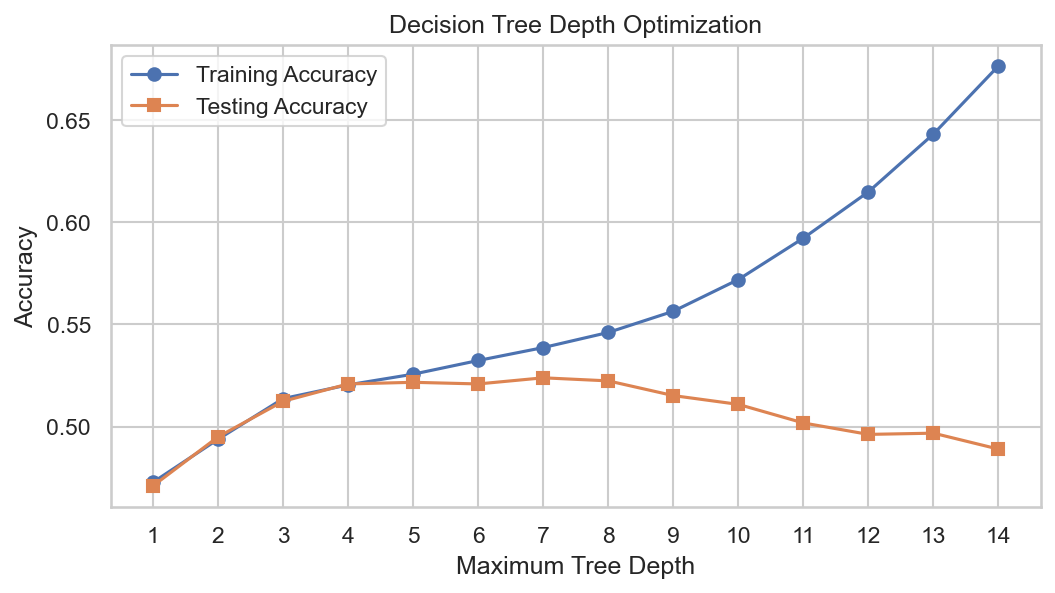

Final model trained with max_depth=7.


In [5]:
# Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)
depths = range(1, 15)
train_scores = []
test_scores = []
models = []

for d in depths:
    temp_model = DecisionTreeClassifier(max_depth=d, random_state=42, criterion='entropy')
    temp_model.fit(X_train, y_train)
    train_scores.append(temp_model.score(X_train, y_train))
    test_scores.append(temp_model.score(X_test, y_test))
    models.append(temp_model)

best_index = np.argmax(test_scores)
OPTIMAL_DEPTH = depths[best_index]

print(f"Optimal depth found: {OPTIMAL_DEPTH} (Test Accuracy: {test_scores[best_index]:.4f})")

# Plot the accuracy vs. depth
plt.figure(figsize=(8, 4))
plt.plot(depths, train_scores, label='Training Accuracy', marker='o')
plt.plot(depths, test_scores, label='Testing Accuracy', marker='s')
plt.xlabel('Maximum Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Depth Optimization')
plt.legend()
plt.xticks(depths)
plt.show()

burnout_model = models[best_index]

print(f"Final model trained with max_depth={OPTIMAL_DEPTH}.")

## Model evaluation
Evaluating and visualizing this models' perforamnce using a Confusion Matrix and Classification Report

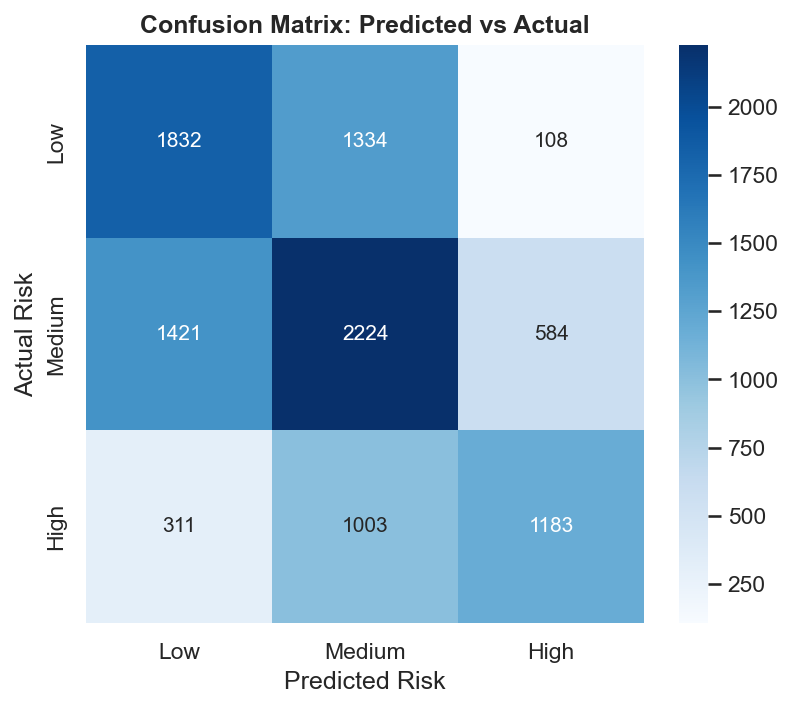


Classification Report:
              precision    recall  f1-score   support

         Low       0.51      0.56      0.54      3274
      Medium       0.49      0.53      0.51      4229
        High       0.63      0.47      0.54      2497

    accuracy                           0.52     10000
   macro avg       0.54      0.52      0.53     10000
weighted avg       0.53      0.52      0.52     10000



In [6]:
y_pred = burnout_model.predict(X_test)

# Confusion Matrix Visualization
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.title("Confusion Matrix: Predicted vs Actual", fontweight='bold')
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=['Low', 'Medium', 'High']))

## Feature Importance
Finding and visualizing the top factors that are affecting student burnout according to this model.

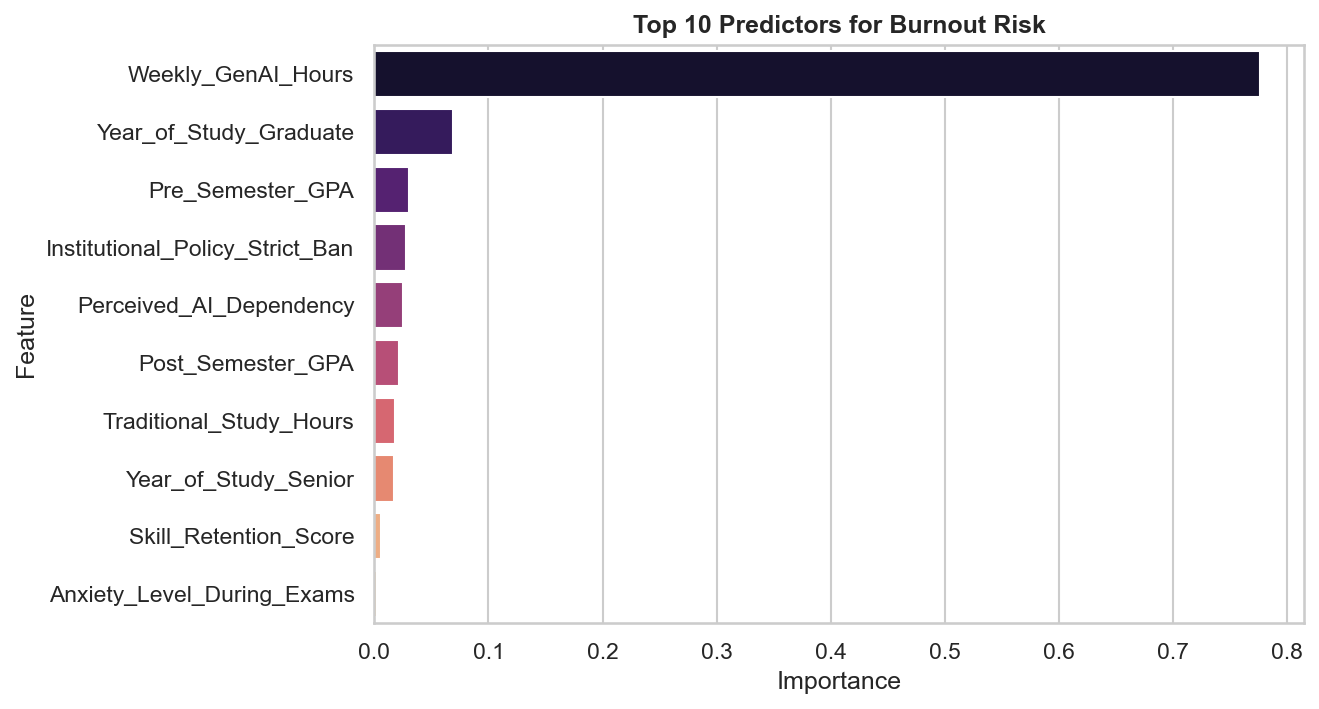

In [7]:
importance = burnout_model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='magma', hue='Feature', legend=False)
plt.title('Top 10 Predictors for Burnout Risk', fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Decision Tree Visualization

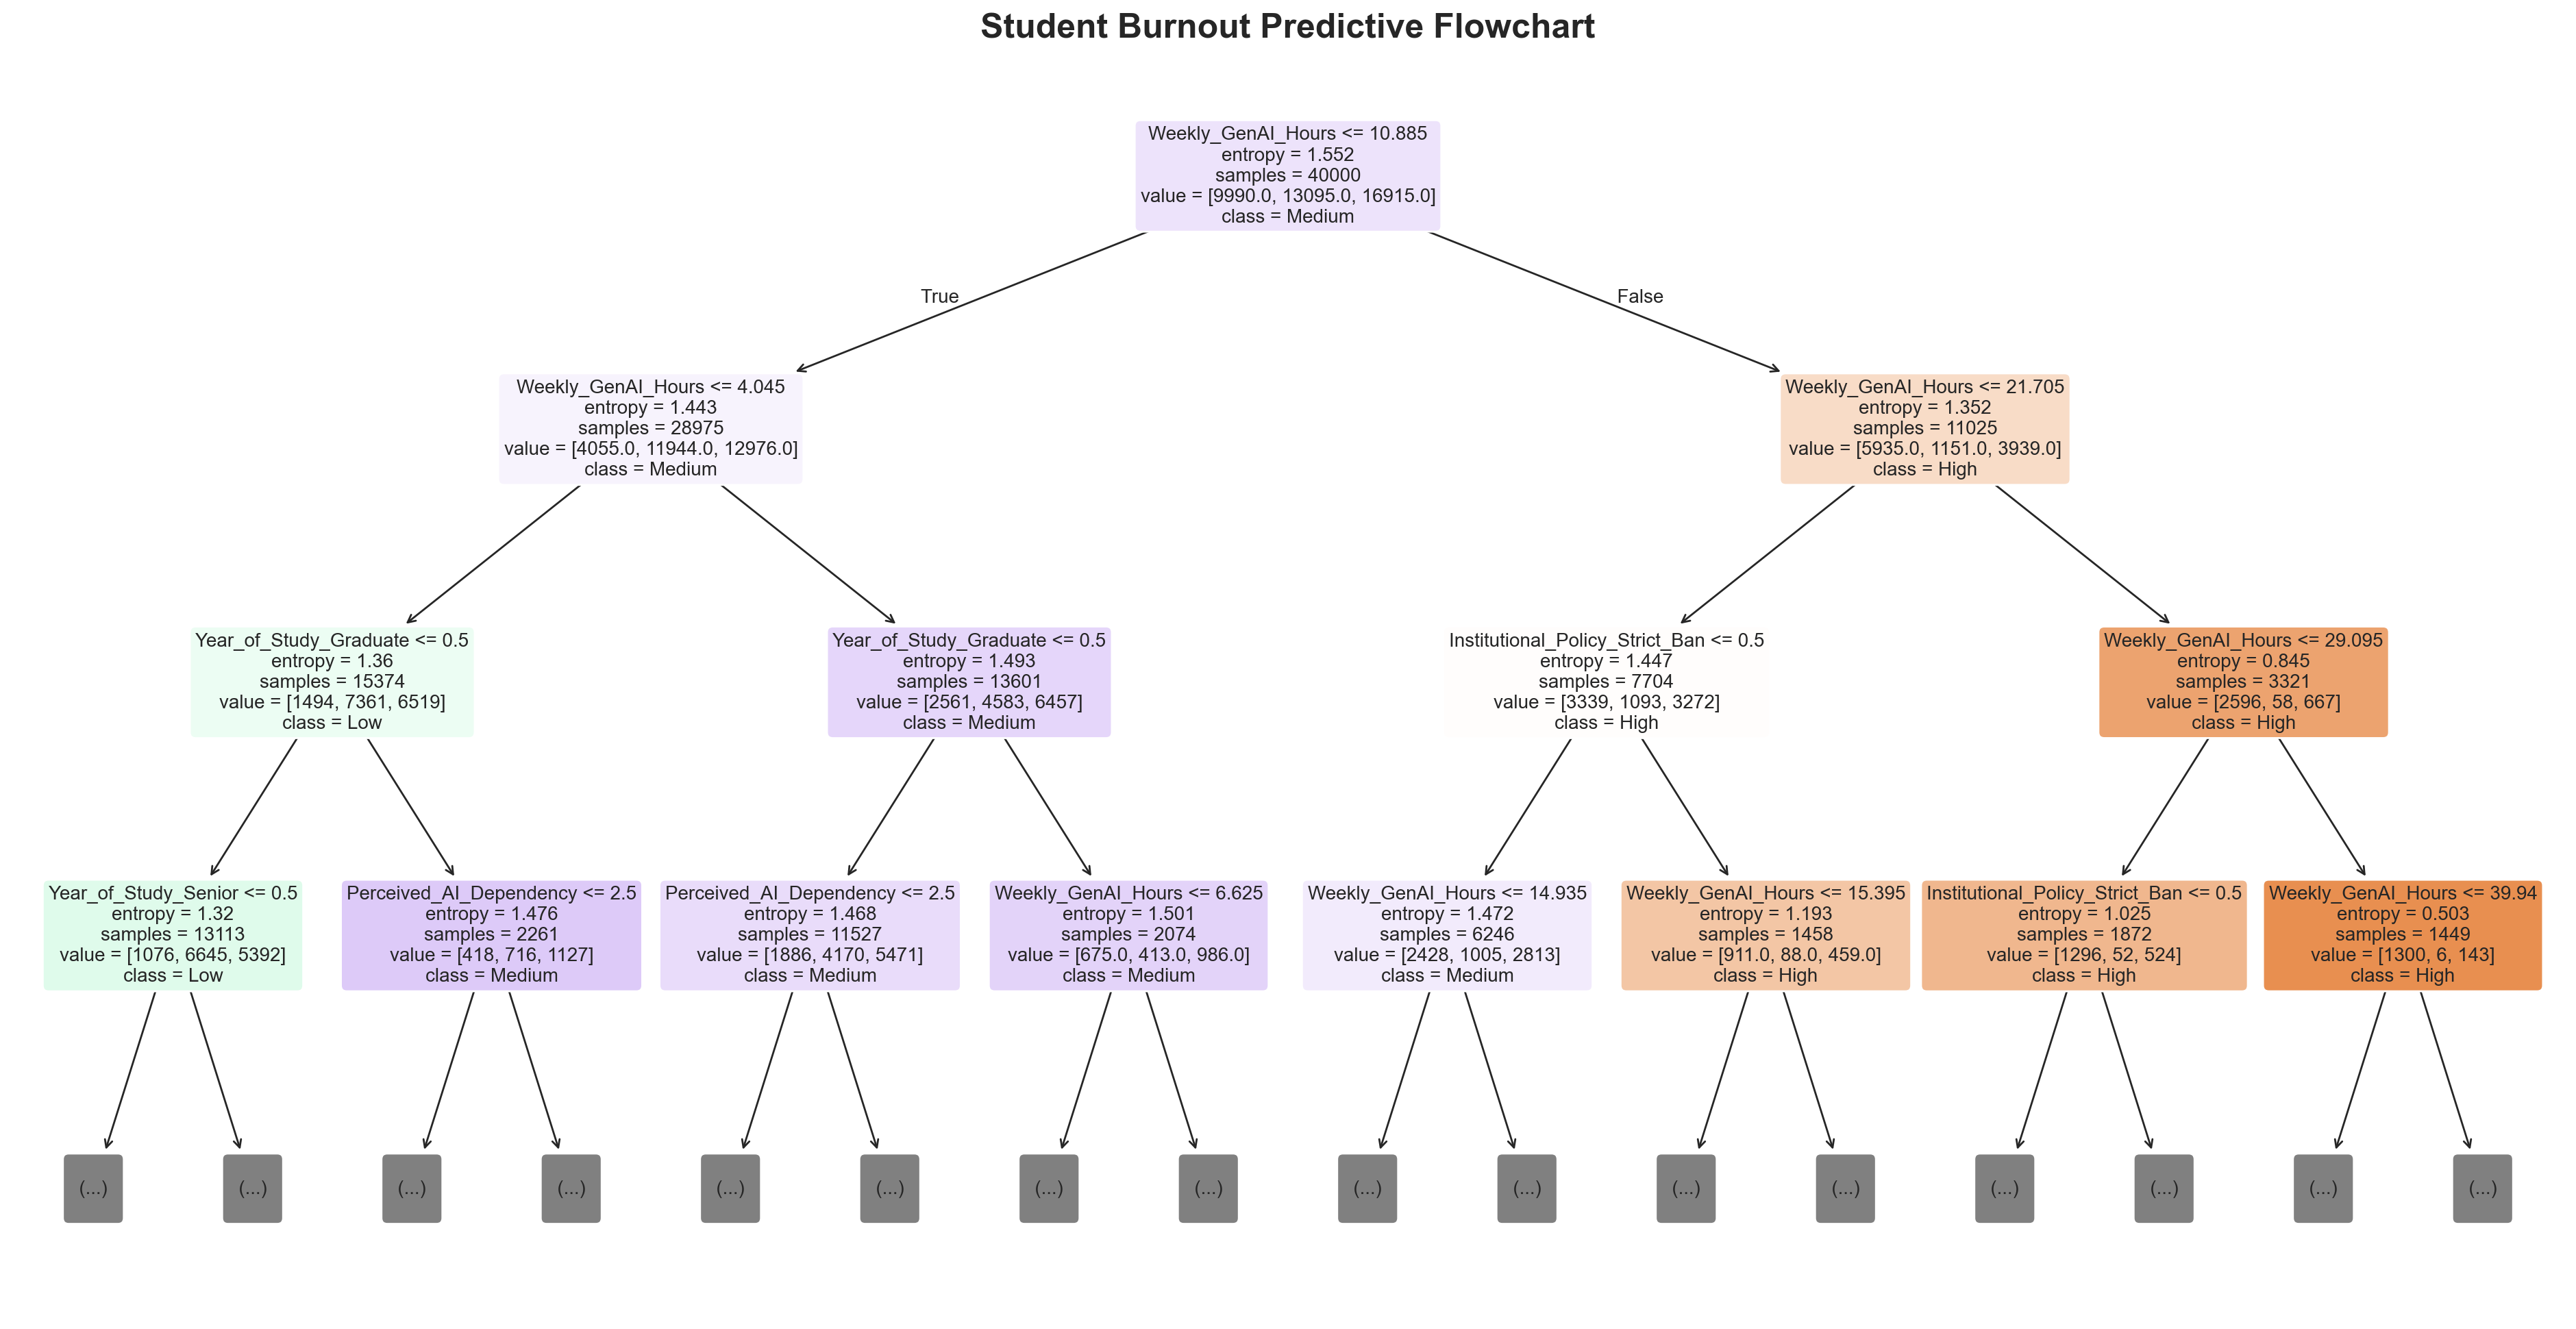

In [8]:
plt.figure(figsize=(24, 12), dpi=200)
plot_tree(
    burnout_model, 
    feature_names=list(X_train.columns), 
    class_names=list(burnout_model.classes_), 
    filled=True, 
    rounded=True, 
    max_depth=3, 
    fontsize=10
)
plt.title("Student Burnout Predictive Flowchart", fontsize=18, fontweight='bold')
plt.show()